# Market-Basket Analysis of IMDB Top 1000 — Frequent Actor Itemsets via A-Priori

**Course:** Algorithms for Massive Data — Master in Data Science for Economics, Università degli Studi di Milano (Prof. Malchiodi)

**Goal:** Treat each movie/show as a *basket* and its leading actors (`Star1`-`Star4`) as *items*. We mine **frequent itemsets of actors** -- i.e. groups of actors who tend to appear together -- using the **A-Priori algorithm implemented from scratch**.

**Dataset:** [IMDB Top 1000 Movies & TV Shows](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows) (Kaggle), file `imdb_top_1000.csv`.

Notebook structure:
1. Configuration
2. Kaggle download
3. Load & clean data
4. Build baskets
5. Exploratory analysis (sparsity / coverage)
6. A-Priori from scratch
7. Results
8. Association rules (confidence, lift)
9. mlxtend cross-check (sanity check only -- not used for the actual mining)


In [1]:
import os

# ----------------------------------------------------------------------------
# Data-size controls (required by the course rubric): the notebook must be
# able to run on the full dataset or on a random subsample, without any
# other code change. Downstream cells read NUM_BASKETS / the actual basket
# list at runtime, so a threshold expressed as a *fraction* of the data
# (see MIN_SUPPORT_FRACTION below) automatically scales to whichever size
# we pick here.
# ----------------------------------------------------------------------------
USE_FULL_DATA = True      # set to False to mine only a random subsample
SAMPLE_SIZE = 200         # only used when USE_FULL_DATA is False
RANDOM_SEED = 42          # for reproducible subsampling

# ----------------------------------------------------------------------------
# Kaggle dataset location
# ----------------------------------------------------------------------------
KAGGLE_DATASET = "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows"
CSV_FILENAME = "imdb_top_1000.csv"
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, CSV_FILENAME)

# ----------------------------------------------------------------------------
# Columns holding the "items" (actors) for each "basket" (movie/show)
# ----------------------------------------------------------------------------
STAR_COLUMNS = ["Star1", "Star2", "Star3", "Star4"]

# ----------------------------------------------------------------------------
# A-Priori support threshold.
#
# We express the threshold as a FRACTION of the number of baskets rather
# than as a fixed count, so the same MIN_SUPPORT_FRACTION value keeps making
# sense whether we run on the full ~1000 movies or on a small sample
# (USE_FULL_DATA = False). The absolute *count* threshold is derived later,
# once we know how many baskets we actually have.
#
# Why 0.003 (0.3%)? Each basket has at most 4 actors, and the actor universe
# is large (most actors appear in only one Top-1000 title), so co-occurring
# pairs are rare by construction. On ~1000 baskets, 0.3% support means "this
# group of actors appeared together in at least ~3 movies/shows" -- low
# enough to surface real recurring collaborations (e.g. actors who did a
# trilogy together), but high enough to filter out pairs that only ever
# shared a single film by coincidence.
# ----------------------------------------------------------------------------
MIN_SUPPORT_FRACTION = 0.003

# Minimum confidence for association rules (Section 6)
MIN_CONFIDENCE = 0.5

print(f"USE_FULL_DATA={USE_FULL_DATA}, SAMPLE_SIZE={SAMPLE_SIZE}, MIN_SUPPORT_FRACTION={MIN_SUPPORT_FRACTION}")


USE_FULL_DATA=True, SAMPLE_SIZE=200, MIN_SUPPORT_FRACTION=0.003


## 1. Download the dataset from Kaggle

We use the official `kaggle` CLI. **No credentials live in this notebook at all** --
the `kaggle` CLI automatically reads them from a local credentials file if one
exists: either `~/.kaggle/access_token` (the newer Kaggle API token) or
`~/.kaggle/kaggle.json` (the older username/key pair). Set one of those up once,
locally, outside this repo, before running this cell. There is nothing to fill in
or restore here before submitting.


In [2]:
import os
import subprocess

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    download_command = [
        "kaggle", "datasets", "download",
        "-d", KAGGLE_DATASET,
        "-p", DATA_DIR,
        "--unzip",
    ]
    result = subprocess.run(download_command, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "Kaggle download failed. Make sure ~/.kaggle/access_token (or "
            "~/.kaggle/kaggle.json) exists locally and contains a valid credential."
        )
else:
    print(f"{CSV_PATH} already present, skipping download.")

assert os.path.exists(CSV_PATH), f"Expected file not found: {CSV_PATH}"
print("Dataset ready at:", CSV_PATH)


data\imdb_top_1000.csv already present, skipping download.
Dataset ready at: data\imdb_top_1000.csv


## 2. Load the CSV and inspect the actor columns

In [3]:
import pandas as pd

raw_df = pd.read_csv(CSV_PATH)
print("Full dataset shape (rows, columns):", raw_df.shape)

print("\nMissing values per Star column:")
print(raw_df[STAR_COLUMNS].isna().sum())

raw_df[STAR_COLUMNS].head()


Full dataset shape (rows, columns): (1000, 16)

Missing values per Star column:
Star1    0
Star2    0
Star3    0
Star4    0
dtype: int64


,Star1,Star2,Star3,Star4
0,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


In [4]:
def clean_actor_name(name):
    """Trim whitespace; return None for missing/empty names."""
    if pd.isna(name):
        return None
    name = str(name).strip()
    return name if name != "" else None


clean_df = raw_df.copy()
for column in STAR_COLUMNS:
    clean_df[column] = clean_df[column].apply(clean_actor_name)

# Apply the data-size control here: either use every movie, or a
# reproducible random subsample of SAMPLE_SIZE movies.
if USE_FULL_DATA:
    working_df = clean_df
else:
    working_df = clean_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

print("Working dataset shape (after USE_FULL_DATA/SAMPLE_SIZE):", working_df.shape)
working_df[STAR_COLUMNS].head()


Working dataset shape (after USE_FULL_DATA/SAMPLE_SIZE): (1000, 16)


,Star1,Star2,Star3,Star4
0,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


## 3. Build baskets: one set of actors per movie/show

In [5]:
def row_to_basket(row):
    """Convert one movie's Star1..Star4 cells into a set of distinct, non-empty actor names."""
    actors_in_row = [row[column] for column in STAR_COLUMNS]
    basket = {actor for actor in actors_in_row if actor is not None}
    return basket


baskets = [row_to_basket(row) for _, row in working_df.iterrows()]

# Drop baskets that ended up empty (e.g. all 4 Star columns missing)
baskets = [basket for basket in baskets if len(basket) > 0]

NUM_BASKETS = len(baskets)
print(f"Number of non-empty baskets: {NUM_BASKETS}")
print("Example basket:", baskets[0])

basket_sizes = pd.Series([len(b) for b in baskets])
print("\nBasket size distribution:")
print(basket_sizes.value_counts().sort_index())


Number of non-empty baskets: 1000
Example basket: {'Bob Gunton', 'William Sadler', 'Morgan Freeman', 'Tim Robbins'}

Basket size distribution:
3      4
4    996
Name: count, dtype: int64


## 4. Exploratory analysis: how sparse is this actor-pair space?

Before mining, it helps to see how sparse the data really is -- it's the reason
the support threshold has to be set so low. We check data quality (missing /
blank actor cells), the basket-size distribution, and how many of all
*possible* actor pairs actually co-occur at least once.


In [6]:
null_pct = raw_df[STAR_COLUMNS].isna().mean() * 100
blank_pct = raw_df[STAR_COLUMNS].apply(
    lambda col: col.astype(str).str.strip().eq("").mean() * 100
)
pd.DataFrame({"null_%": null_pct, "blank_%": blank_pct}).round(2)


,null_%,blank_%
Star1,0.0,0.0
Star2,0.0,0.0
Star3,0.0,0.0
Star4,0.0,0.0


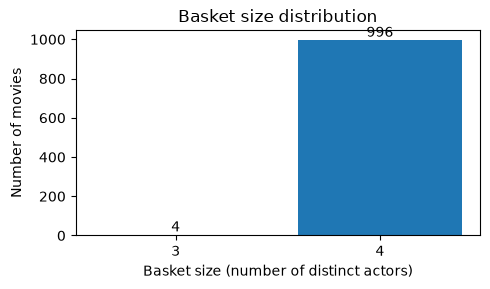

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

basket_size_counts = Counter(len(basket) for basket in baskets)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(basket_size_counts.keys(), basket_size_counts.values())
ax.bar_label(bars)
ax.set_xlabel("Basket size (number of distinct actors)")
ax.set_ylabel("Number of movies")
ax.set_title("Basket size distribution")
ax.set_xticks(sorted(basket_size_counts.keys()))
plt.tight_layout()
plt.show()


In [8]:
from itertools import combinations
from math import comb

actor_frequency = pd.Series(
    [actor for basket in baskets for actor in basket]
).value_counts()

print(f"Distinct actors across all baskets: {len(actor_frequency)}")
print("\nTop 10 most frequent actors:")
print(actor_frequency.head(10))

# Every pair of actors that co-starred in at least one basket, vs. every
# pair that COULD exist among the actors we have.
observed_pairs = set()
for basket in baskets:
    for pair in combinations(sorted(basket), 2):
        observed_pairs.add(pair)

num_actors = len(actor_frequency)
num_possible_pairs = comb(num_actors, 2)
num_observed_pairs = len(observed_pairs)
coverage = num_observed_pairs / num_possible_pairs

print(f"\nDistinct actors (N):           {num_actors}")
print(f"Possible actor pairs C(N,2):    {num_possible_pairs:,}")
print(f"Observed co-occurring pairs:    {num_observed_pairs:,}")
print(f"Coverage (observed/possible):   {coverage * 100:.4f}%")
print(
    "\nThe actor-pair space is extremely sparse: almost every possible pair "
    "of actors has never co-starred. This is the empirical justification for "
    "MIN_SUPPORT_FRACTION being so low -- requiring even ~3 shared movies out "
    "of ~1000 baskets already isolates genuinely repeated collaborations."
)


Distinct actors across all baskets: 2709

Top 10 most frequent actors:
Robert De Niro       17
Tom Hanks            14
Al Pacino            13
Brad Pitt            12
Clint Eastwood       12
Christian Bale       11
Leonardo DiCaprio    11
Matt Damon           11
James Stewart        10
Michael Caine         9
Name: count, dtype: int64

Distinct actors (N):           2709
Possible actor pairs C(N,2):    3,667,986
Observed co-occurring pairs:    5,833
Coverage (observed/possible):   0.1590%

The actor-pair space is extremely sparse: almost every possible pair of actors has never co-starred. This is the empirical justification for MIN_SUPPORT_FRACTION being so low -- requiring even ~3 shared movies out of ~1000 baskets already isolates genuinely repeated collaborations.


## 5. A-Priori algorithm, implemented from scratch

The classic A-Priori idea, applied here:

- **Pass 1**: count every individual actor's support (how many baskets contain
  them); keep the *frequent singletons*.
- **Pass k (k >= 2)**:
  1. **Candidate generation (join step)** -- combine pairs of frequent itemsets
     of size `k-1` that share `k-2` items, to build candidate itemsets of size `k`.
  2. **Pruning (downward-closure)** -- discard any candidate whose own size-`(k-1)`
     subsets are not *all* already known to be frequent (if a subset isn't
     frequent, the superset can't be either).
  3. **Counting** -- scan every basket and count how many baskets contain each
     surviving candidate.
  4. Keep candidates whose count meets the support threshold as the frequent
     itemsets of size `k`.
- Stop when a pass produces no new frequent itemsets, or when `k` exceeds the
  basket size (here, baskets have at most 4 actors, so `k` never needs to
  exceed 4).

We derive the absolute **support-count threshold** from `MIN_SUPPORT_FRACTION`
and the actual number of baskets, so the threshold automatically adapts to
`USE_FULL_DATA` / `SAMPLE_SIZE`.


In [9]:
import math
from itertools import combinations

MIN_SUPPORT_COUNT = math.ceil(MIN_SUPPORT_FRACTION * NUM_BASKETS)
print(
    f"NUM_BASKETS={NUM_BASKETS}, MIN_SUPPORT_FRACTION={MIN_SUPPORT_FRACTION} "
    f"=> MIN_SUPPORT_COUNT={MIN_SUPPORT_COUNT}"
)


def count_candidates(baskets, candidate_itemsets):
    """
    Scan every basket once and count, for each candidate itemset, how many
    baskets contain it as a subset. Returns a dict {itemset: count}.
    """
    counts = {candidate: 0 for candidate in candidate_itemsets}
    for basket in baskets:
        for candidate in candidate_itemsets:
            if candidate.issubset(basket):
                counts[candidate] += 1
    return counts


NUM_BASKETS=1000, MIN_SUPPORT_FRACTION=0.003 => MIN_SUPPORT_COUNT=3


In [10]:
# ----------------------------------------------------------------------------
# Pass 1: frequent singletons
# ----------------------------------------------------------------------------
# Every distinct actor is a size-1 candidate. We reuse count_candidates so the
# counting logic is identical to every later pass.
all_actors = set()
for basket in baskets:
    all_actors.update(basket)

singleton_candidates = {frozenset([actor]) for actor in all_actors}
singleton_counts = count_candidates(baskets, singleton_candidates)

frequent_itemsets_by_size = {}
frequent_itemsets_by_size[1] = {
    itemset: count
    for itemset, count in singleton_counts.items()
    if count >= MIN_SUPPORT_COUNT
}

print(f"Distinct actors: {len(all_actors)}")
print(f"Frequent singletons (count >= {MIN_SUPPORT_COUNT}): {len(frequent_itemsets_by_size[1])}")


Distinct actors: 2709
Frequent singletons (count >= 3): 271


In [11]:
def generate_candidates_join(frequent_itemsets_prev_size, k):
    """
    A-Priori candidate generation (join step).

    Given the frequent itemsets of size (k-1), build candidates of size k by
    unioning every pair of frequent (k-1)-itemsets that share exactly k-2
    items in common (so their union has exactly k items).
    """
    previous_itemsets = list(frequent_itemsets_prev_size)
    candidates = set()

    for i in range(len(previous_itemsets)):
        for j in range(i + 1, len(previous_itemsets)):
            union_itemset = previous_itemsets[i] | previous_itemsets[j]
            if len(union_itemset) == k:
                candidates.add(union_itemset)

    return candidates


def prune_candidates_by_downward_closure(candidates, frequent_itemsets_prev_size, k):
    """
    Downward-closure pruning: a candidate of size k can only be frequent if
    ALL of its size-(k-1) subsets are themselves frequent. We discard any
    candidate that has at least one infrequent subset, without ever having
    to count it against the data.
    """
    surviving_candidates = set()

    for candidate in candidates:
        all_subsets_frequent = True
        for subset_tuple in combinations(candidate, k - 1):
            subset = frozenset(subset_tuple)
            if subset not in frequent_itemsets_prev_size:
                all_subsets_frequent = False
                break
        if all_subsets_frequent:
            surviving_candidates.add(candidate)

    return surviving_candidates


In [12]:
# ----------------------------------------------------------------------------
# Passes 2, 3, 4, ...: iteratively build larger frequent itemsets
# ----------------------------------------------------------------------------
k = 2
while True:
    previous_frequent = frequent_itemsets_by_size.get(k - 1, {})
    if len(previous_frequent) == 0:
        # nothing frequent at the previous size, so nothing can be built on top of it
        print(f"k={k}: no frequent itemsets of size {k - 1} to extend, stopping.")
        break

    candidates = generate_candidates_join(previous_frequent.keys(), k)
    candidates = prune_candidates_by_downward_closure(candidates, previous_frequent.keys(), k)

    if len(candidates) == 0:
        print(f"k={k}: 0 candidates survived the join + downward-closure pruning, stopping.")
        break

    candidate_counts = count_candidates(baskets, candidates)

    frequent_at_k = {
        itemset: count
        for itemset, count in candidate_counts.items()
        if count >= MIN_SUPPORT_COUNT
    }

    print(f"k={k}: {len(candidates)} candidates after pruning -> {len(frequent_at_k)} frequent itemsets")

    if len(frequent_at_k) == 0:
        break

    frequent_itemsets_by_size[k] = frequent_at_k
    k += 1

print("\nDone. Frequent itemset sizes found:", sorted(frequent_itemsets_by_size.keys()))


k=2: 36585 candidates after pruning -> 25 frequent itemsets
k=3: 4 candidates after pruning -> 3 frequent itemsets
k=4: 0 candidates survived the join + downward-closure pruning, stopping.

Done. Frequent itemset sizes found: [1, 2, 3]


## 6. Results: frequent actor itemsets

In [13]:
results_rows = []
for size, itemsets in frequent_itemsets_by_size.items():
    for itemset, count in itemsets.items():
        results_rows.append({
            "size": size,
            "actors": ", ".join(sorted(itemset)),
            "count": count,
            "support": count / NUM_BASKETS,
        })

results_df = pd.DataFrame(results_rows).sort_values(
    by=["size", "count"], ascending=[True, False]
).reset_index(drop=True)

print(f"Total frequent itemsets found: {len(results_df)}")
results_df


Total frequent itemsets found: 299


,size,actors,count,support
0,1,Robert De Niro,17,0.017
1,1,Tom Hanks,14,0.014
2,1,Al Pacino,13,0.013
3,1,Brad Pitt,12,0.012
4,1,Clint Eastwood,12,0.012
...,...,...,...,...
294,2,"Al Pacino, Diane Keaton",3,0.003
295,2,"Ethan Hawke, Julie Delpy",3,0.003
296,3,"Daniel Radcliffe, Emma Watson, Rupert Grint",5,0.005
297,3,"Carrie Fisher, Harrison Ford, Mark Hamill",3,0.003


In [14]:
for size in sorted(frequent_itemsets_by_size.keys()):
    print(f"\n=== Frequent itemsets of size {size} (top 10 by count) ===")
    display(results_df[results_df["size"] == size].head(10))



=== Frequent itemsets of size 1 (top 10 by count) ===


,size,actors,count,support
0,1,Robert De Niro,17,0.017
1,1,Tom Hanks,14,0.014
2,1,Al Pacino,13,0.013
3,1,Brad Pitt,12,0.012
4,1,Clint Eastwood,12,0.012
5,1,Leonardo DiCaprio,11,0.011
6,1,Christian Bale,11,0.011
7,1,Matt Damon,11,0.011
8,1,James Stewart,10,0.010
9,1,Humphrey Bogart,9,0.009



=== Frequent itemsets of size 2 (top 10 by count) ===


,size,actors,count,support
271,2,"Daniel Radcliffe, Rupert Grint",6,0.006
272,2,"Daniel Radcliffe, Emma Watson",5,0.005
273,2,"Emma Watson, Rupert Grint",5,0.005
274,2,"Joe Pesci, Robert De Niro",4,0.004
275,2,"Tim Allen, Tom Hanks",4,0.004
276,2,"Mark Ruffalo, Robert Downey Jr.",3,0.003
277,2,"Al Pacino, Robert De Niro",3,0.003
278,2,"Humphrey Bogart, Lauren Bacall",3,0.003
279,2,"Carrie Fisher, Mark Hamill",3,0.003
280,2,"Chris Evans, Scarlett Johansson",3,0.003



=== Frequent itemsets of size 3 (top 10 by count) ===


,size,actors,count,support
296,3,"Daniel Radcliffe, Emma Watson, Rupert Grint",5,0.005
297,3,"Carrie Fisher, Harrison Ford, Mark Hamill",3,0.003
298,3,"Elijah Wood, Ian McKellen, Orlando Bloom",3,0.003


## 7. (Optional) Association rules: confidence and lift

For every frequent itemset of size >= 2, we generate rules `antecedent => consequent`
(splitting the itemset into a non-empty proper subset and its complement) and compute:

- **confidence(A => B)** = support(A union B) / support(A) -- how often B appears with A.
- **lift(A => B)** = confidence(A => B) / support(B) -- how much more often A and B
  occur together than if they were independent (lift > 1 means positive association).

We keep only rules with confidence >= `MIN_CONFIDENCE`.


In [15]:
rule_rows = []
for size, itemsets in frequent_itemsets_by_size.items():
    if size < 2:
        continue  # rules need at least one item on each side

    for itemset, itemset_count in itemsets.items():
        items = list(itemset)
        # Try every non-empty proper subset as the antecedent
        for antecedent_size in range(1, size):
            for antecedent_tuple in combinations(items, antecedent_size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                # Downward closure guarantees both antecedent and consequent
                # are themselves frequent itemsets we already tracked.
                antecedent_count = frequent_itemsets_by_size[len(antecedent)][antecedent]
                confidence = itemset_count / antecedent_count

                if confidence < MIN_CONFIDENCE:
                    continue

                consequent_count = frequent_itemsets_by_size[len(consequent)][consequent]
                consequent_support = consequent_count / NUM_BASKETS
                lift = confidence / consequent_support

                rule_rows.append({
                    "antecedent": ", ".join(sorted(antecedent)),
                    "consequent": ", ".join(sorted(consequent)),
                    "confidence": confidence,
                    "lift": lift,
                    "itemset_count": itemset_count,
                })

rules_df = pd.DataFrame(rule_rows).sort_values(by="lift", ascending=False).reset_index(drop=True)
print(f"Total rules with confidence >= {MIN_CONFIDENCE}: {len(rules_df)}")
rules_df.head(20)


Total rules with confidence >= 0.5: 46


,antecedent,consequent,confidence,lift,itemset_count
0,"Ian McKellen, Orlando Bloom",Elijah Wood,1.000000,333.333333,3
1,Elijah Wood,"Ian McKellen, Orlando Bloom",1.000000,333.333333,3
2,Mark Hamill,"Carrie Fisher, Harrison Ford",1.000000,333.333333,3
3,"Carrie Fisher, Harrison Ford",Mark Hamill,1.000000,333.333333,3
4,Carrie Fisher,Mark Hamill,0.750000,250.000000,3
5,Mark Hamill,Carrie Fisher,1.000000,250.000000,3
6,"Elijah Wood, Ian McKellen",Orlando Bloom,1.000000,250.000000,3
7,Orlando Bloom,"Elijah Wood, Ian McKellen",0.750000,250.000000,3
8,Elijah Wood,Orlando Bloom,1.000000,250.000000,3
9,Orlando Bloom,Elijah Wood,0.750000,250.000000,3


## 8. (Optional) Cross-check against mlxtend

This cell is **only a correctness sanity check** -- it re-runs frequent-itemset
mining with `mlxtend`'s implementation on the same baskets and same support
threshold, then compares the resulting itemsets against our from-scratch
results. It is not part of the required implementation.

Requires `mlxtend` (`pip install mlxtend`).


In [16]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori

encoder = TransactionEncoder()
one_hot_array = encoder.fit(baskets).transform(baskets)
one_hot_df = pd.DataFrame(one_hot_array, columns=encoder.columns_)

mlxtend_results = mlxtend_apriori(
    one_hot_df, min_support=MIN_SUPPORT_FRACTION, use_colnames=True
)
mlxtend_results["size"] = mlxtend_results["itemsets"].apply(len)

# Build a comparable {itemset: rounded support} dict from mlxtend output
mlxtend_itemsets = {
    frozenset(itemset): round(support, 6)
    for itemset, support in zip(mlxtend_results["itemsets"], mlxtend_results["support"])
}

# Build the same shape from our own results
our_itemsets = {
    itemset: round(count / NUM_BASKETS, 6)
    for size, itemsets in frequent_itemsets_by_size.items()
    for itemset, count in itemsets.items()
}

only_in_mlxtend = set(mlxtend_itemsets) - set(our_itemsets)
only_in_ours = set(our_itemsets) - set(mlxtend_itemsets)
support_mismatches = {
    itemset: (our_itemsets[itemset], mlxtend_itemsets[itemset])
    for itemset in set(our_itemsets) & set(mlxtend_itemsets)
    if our_itemsets[itemset] != mlxtend_itemsets[itemset]
}

print(f"Our frequent itemsets: {len(our_itemsets)}")
print(f"mlxtend frequent itemsets: {len(mlxtend_itemsets)}")
print(f"Itemsets only found by mlxtend: {len(only_in_mlxtend)}")
print(f"Itemsets only found by us: {len(only_in_ours)}")
print(f"Itemsets with mismatched support: {len(support_mismatches)}")

assert only_in_mlxtend == set(), f"Missing itemsets: {only_in_mlxtend}"
assert only_in_ours == set(), f"Extra itemsets: {only_in_ours}"
assert support_mismatches == {}, f"Support mismatches: {support_mismatches}"
print("\nCross-check passed: our from-scratch A-Priori matches mlxtend exactly.")


Our frequent itemsets: 299
mlxtend frequent itemsets: 299
Itemsets only found by mlxtend: 0
Itemsets only found by us: 0
Itemsets with mismatched support: 0

Cross-check passed: our from-scratch A-Priori matches mlxtend exactly.
